## Week 5: Introduction to Transformers
https://poloclub.github.io/transformer-explainer/
### 5.1: Self attention
Now that we understand how sequence information can be represented by vector embeddings, we can start building an intuition for how to embed the properties of text data into inductive biases suitable for training. 

Let us now consider a sequence of tokens represented by $x$.

\begin{equation*}
    x = \{ x_1, x_2, x_3, ... x_N \}
\end{equation*}

where $N$ refers to the maximum token size that can be accomodated in the context. The set $x$ is called the _context_. Each element of this set $x_i$ is a vector of size $(1,d)$ where $d$ is the size of embedding

An important property of sequence type of data is long-range dependancy of arbitrary length. A token $x_i$ can depend on any other token in context. How can we represent that? 


#### 5.1.1 Computing attention as a dot product
Long range dependancy between two input embeddings are computed as attention scores between them. Attention between two embedding vectors are computed as the dot product between them. When two vectors point in the same direction, they have higher dot product and therefore higher attention scores. 

Here is the formula for dot product. 

\begin{equation*}
    \vec{u} \cdot \vec{v} = |u| |v| cos(\theta)
\end{equation*}

where $\theta$ is the angle between two vectors. Play with the interactive sliders below to get an intuition for the relationship between alignment and the dot product between two vectors. 

In [2]:
from src.utils import interactive_dot_product

interactive_dot_product()

#### 5.1.2 Projecting inputs to low-dimensional space
Attention is computed between the projections of input embeddings. The different projections that we use are: 

- Query:    What does a token need? 
- Key:      What does a token provide? 

Attention is computed as the dot product between the Query and Key vectors of all input tokens. Attention between two embeddings is the dot product of what one vector wants and what the other can provide. The value vectors corresponding to each input token are then mixed with other value vectors using a weighted average.

The query, key and value vectors are computed using linear mapping using learned weight matrices $W_q$, $W_k$ and $W_v$ respectively. The query and key vectors are generally projected to a lower dimensional space within calculation of attention called the _head dimension_, $d_h$. So consequently the weight matrices for query and key have the shape $(d, d_h)$ Generally, $d_h$ and $d_v$ are the same. 

For an input vector $x_i$, the projections are computed as

\begin{equation*}
    q_i = x_i W_q
\end{equation*}

\begin{equation*}
    k_i = x_i W_k
\end{equation*}


In [16]:
import numpy as np
from src.utils import interactive_qk_vectors
x_1 = np.array([1.0, 0.5, -0.8])
x_2 = np.array([-0.4, 1.1, 1.2])
W_q = np.array([[0.92, -0.89], [0.94, 1.13], [-0.11, .99]])
W_k = np.array([[0.45, 0.67], [-0.56, 0.78], [1.23, -0.34]])
interactive_qk_vectors(x_1, x_2, W_q, W_k)

Output()

>> NEED TO CLARIFY
>> HERE WE ARE IMPOSING ROTATION SO BOTH Q1 AND Q2 ROTATE TOGETHER
>> It does not have to be that way. The angle between Q1 and Q2 can change depending on the weight matrix. What is common is that we impose the same weight matrix and this results in highlighting particular relationship between tokens.  So we need multiple heads. 


In this above demonstration, the input embedding vectors $x_1$ and $x_2$ are projected to corresponding query and key vectors $q_1, k_1$ and $q_2, k_2$ respectively. The weight matrices are shared across tokens. Maximising alignment between $q_1$ and $k_2$ hurts other alignments that might be present in the data. Thus, a single attention mechanism imposes shared geometric constraint over the tokens. As we will see later, this means we need multiple heads looking at different shared relationship across tokens to capture full relationship between the tokens. 

Next we will see how attention scores are used to mix contextual information between tokens. This is done by computing another projection called the value vector. This is again a linear projection of hte input embedding, computed using another learned weight matrix $W_v$. The value vectors are projected to $d_v$. The value matrix has the shape $(d, d_v)$. The shape of value vectors can be different from head dimension, but is typically set the same. 
\begin{equation*}
    v_i = x_i W_v
\end{equation*}

Run the following interactive to visualise all the three projections for the input embeddings mapped together. Here we use the head dimension to be 2 and is the same for value vector as well. 


In [17]:
from src.utils import interactive_qkv_vectors
W_v = np.array([[0.34, -0.56], [0.78, 0.12], [-0.45, 1.23]])
interactive_qkv_vectors(x_1, x_2, W_q, W_k, W_v)

Output()

#### 5.1.3 Computing output value vectors through attention 
Attention between $x_i$ and the other vectors in the input context is given by the scores:

\begin{equation*}
    A_i = \big[\, q_i \cdot k_j \,\big]_{j=1}^{N}
\end{equation*}

where $N$ is the size of the input sequence. These raw scores are normalised with a softmax to produce attention weights that sum to one:

\begin{equation*}
    \alpha_{ij} = \mathrm{softmax}_j\!\left(\frac{q_i \cdot k_j}{\sqrt{d_h}}\right)
              = \frac{\exp(q_i \cdot k_j / \sqrt{d_h})}{\sum_{l=1}^{N} \exp(q_i \cdot k_l / \sqrt{d_h})}
\end{equation*}

Finally, the output for token $i$ is the weighted average of all value vectors:

\begin{equation*}
    v_{i,\text{out}} = \sum_{j=1}^{N} \alpha_{ij}\, v_{j}
\end{equation*}

Run the next code cell to understand how context informs output value vectors. 

In [1]:
from src.utils import interactive_attention

interactive_attention()

Output()

#### 5.1.4 Projecting the attention output back to embedding space

The attention output for each token, $v_{i,\text{out}} = \sum_j \alpha_{ij} v_j$, is the
weighted sum of value vectors computed in the previous step. It lives in the value
space ($\mathbb{R}^{d_v}$) and must be projected back to the original embedding space
($\mathbb{R}^{d}$) before it can be passed on. A learned **output projection** $W_O$
does this:

\begin{equation*}
    x_{i,\text{out}} = v_{i,\text{out}} W_O 
\end{equation*}

where $W_O$ has shape $(d_v, d)$, the bias $b$ has shape $(1, d)$. 

Run the next code cell to see the attention output reflected back into the embedding space.

In [1]:
from src.utils import interactive_attention_with_output

interactive_attention_with_output()

Output()

In [42]:
import numpy as np 
class SelfAttention:
    def __init__(self, d_model, return_attention_weights=False):
        self.d_model = d_model 
        # Initialize the weight matrices for query, key, and value
        self.W_Q = np.random.rand(d_model, d_model)
        self.W_K = np.random.rand(d_model, d_model)
        self.W_V = np.random.rand(d_model, d_model)
        
        self.return_attention_weights = return_attention_weights


    def forward(self, x, forward_mask=None):
        # x is the input embedding vector of shape (batch_size, seq_length, d_model)
        # Compute the query, key, and value matrices
        print("x shape:", x.shape)
        print("W_Q shape:", self.W_Q.shape)
        
        Q = x @ self.W_Q.T
        K = x @ self.W_K.T
        V = x @ self.W_V.T

        # Compute the attention scores
        A = Q @ K.T 
        # Scale the attention scores
        A = A / np.sqrt(self.d_model)
        A = A/A.max()  # Normalize for numerical stability
        # Apply the forward mask if provided (e.g., for causal attention)
        if forward_mask is not None:
            A = A * forward_mask
        # Apply softmax to get the attention weights
        A = np.exp(A) 

        A = A / np.sum(A, axis=-1, keepdims=True)
        # Compute the output as a weighted sum of the value vectors
        output = A @ V
        if self.return_attention_weights:
            return output, A
        else:
            return output

In [43]:
# Example usage
d_model = 64
self_attention = SelfAttention(d_model, return_attention_weights=True)
batch_size = 1
seq_length = 10
# Random input embedding vector
x = np.random.rand(seq_length, d_model)
print("x shape:", x.shape)  # Should be (batch_size, seq_length, d_model)
output, attention_weights = self_attention.forward(x)

print("Output shape:", output.shape)  # Should be (batch_size, seq_length, d_model)
print("Attention weights shape:", attention_weights.shape)  # Should be (batch_size, seq_length, seq_length)



x shape: (10, 64)
x shape: (10, 64)
W_Q shape: (64, 64)
Output shape: (10, 64)
Attention weights shape: (10, 10)


In [50]:
attention_weights

array([[0.1025581 , 0.09862545, 0.10376338, 0.09670002, 0.09117406,
        0.09448227, 0.10459269, 0.10678944, 0.0993841 , 0.10193049],
       [0.10239994, 0.09867016, 0.1035354 , 0.09687131, 0.09164509,
        0.09477607, 0.10439028, 0.10644819, 0.0994339 , 0.10182965],
       [0.1024714 , 0.09867148, 0.10372128, 0.09670696, 0.09120413,
        0.09449888, 0.10461445, 0.106796  , 0.09938312, 0.1019323 ],
       [0.10230055, 0.09875493, 0.10343051, 0.09700032, 0.09194995,
        0.09494793, 0.10422038, 0.10617542, 0.09943002, 0.10178999],
       [0.10222544, 0.09877736, 0.10328652, 0.09715901, 0.09224196,
        0.09518305, 0.10402251, 0.10596506, 0.0994628 , 0.1016763 ],
       [0.10225259, 0.0987744 , 0.10337281, 0.09701399, 0.09206586,
        0.09503987, 0.10417526, 0.10607605, 0.09947477, 0.1017544 ],
       [0.10249933, 0.09862122, 0.10377322, 0.09667751, 0.09113542,
        0.09443533, 0.10466799, 0.10684343, 0.09939414, 0.10195241],
       [0.10252809, 0.09861012, 0.1038161

[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


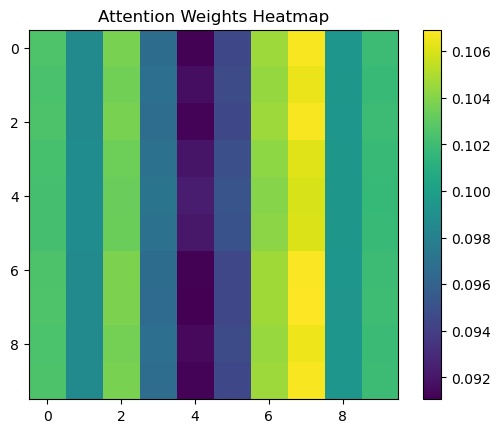

In [45]:
# show heatmap of attention weights
import matplotlib.pyplot as plt
plt.imshow(attention_weights, cmap='viridis')
plt.colorbar()
plt.title('Attention Weights Heatmap')
print(attention_weights.sum(axis=1))  # Should be close to 1 for each row

- History of transformers
- Where are they used? 
- Why is it suitable for sequence data types

#### 2: Architecture of Transformers
(Understand the information flow in the architecture,
 inductive bias for sequence data) 
 - Self Attention as directed graphs
 - Multi-head attention
 - Layer Normalization
 - MLP : Why do we need an additional MLP layer? 

#### 3: Activity? 
 - Can we form groups of 5 people to form an example of multi-head attention?
 - Goal is to predict: "The cat sat on the ___"
 - Each group represents on attention head. Each person in the group represents one token in the input sequence.
 - Pre-computed weight matrices given
 - Need to figure out interpretable dimensions for embedding vector (though it is a simplification)


#### 4: Training a Transformer
 - Auto-regressive language modeling
 - Masked language modeling for bidirectional context
 - Input: tokenized text, positional encoding
 - Output: probability distribution over the vocabulary 
 - Loss function: Cross-entropy loss 
 - Show training loop for one example (tiny shakespeare? Monty Python? Ask students to bring their own text?)

 